In [1]:
import sys; sys.path.append('..') ## proejct root
from methods.config import *
import methods.genomics_util as genomics
import methods.shared as shared

import numpy as np; rnd=np.random.default_rng()
import matplotlib.pyplot as plt; import matplotlib as mpl
import methods.plot_utils as plot_utils
import pickle

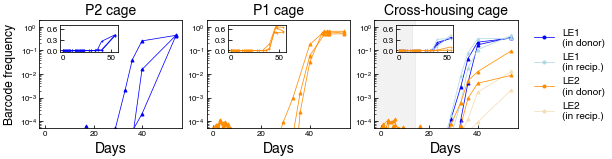

In [ ]:

expt = 'E1'

fig = plt.figure(figsize=(10, 2))
gs = plt.GridSpec(nrows=1, ncols=4, width_ratios=(1,1,1,0.38), figure=fig)
axs = [fig.add_subplot(gs[i]) for i in range(0,3)]
lin_axes = {ax_idx:axs[ax_idx].inset_axes([0.15, 0.7, 0.4, 0.25]) for ax_idx in [0,1,2]}

legend_ax = fig.add_subplot(gs[-1])
plot_utils.turn_off_ax(legend_ax)
legend_markers = [mpl.lines.Line2D((0,0), (0,0), marker='.', color=c) \
                  for c in ['blue', 'lightblue', 'darkorange', 'wheat']]
legend_labels = ['LE1\n(in donor)', 'LE1\n(in recip.)', 'LE2\n(in donor)', 'LE2\n(in recip.)']
legend_ax.legend(legend_markers, legend_labels, loc='center', frameon=False, fontsize=10)

for r, (barcode, mice, ax_idx, kwargs) in enumerate([(shared.LE1, [1,2,3], 0, {'color':'blue'}),
                                                      (shared.LE2, [1,2,3], 0, {'color':'wheat'}),
                                                      (shared.LE2, [8,9,10], 1, {'color':'darkorange'}),
                                                      (shared.LE1, [8,9,10], 1, {'color':'lightblue'}),
                                                      (shared.LE1, [4,5], 2, {'color':'blue'}),
                                                      (shared.LE1, [6,7], 2, {'color':'lightblue'}),
                                                      (shared.LE2, [4,5], 2, {'color':'wheat'}),
                                                      (shared.LE2, [6,7], 2, {'color':'darkorange'})]):
    ax = axs[ax_idx]
    lin_ax = lin_axes[ax_idx]

    bc_index = np.where(shared.barcodes == barcode)[0][0]


    for mouse in mice:
        days, reads, depths = shared.get_mouse_timecourse(expt, mouse, min_depth=10**4)
        bc_freqs = shared.calc_freqs(reads,depths)[:, bc_index]
        bc_freqs[bc_freqs == 0] = 1e-7
        bc_logit = np.log(bc_freqs / (1-bc_freqs))


        if (mouse in [1,2,3])*(barcode == shared.LE2) or (mouse in [8,9,10])*(barcode == shared.LE1):
            continue
        elif (mouse in [1,2,3])*(barcode == shared.LE2) or (mouse in [8,9,10])*(barcode == shared.LE1):
            ax.plot(days, bc_freqs, label=mouse, marker='.', markersize=3, **kwargs)
            lin_ax.plot(days, bc_freqs, label=mouse, marker='.', markersize=1, **kwargs)
        else:
            ax.plot(days, bc_freqs, label=mouse, marker='^', markersize=3, **kwargs)
            lin_ax.plot(days, bc_freqs, label=mouse, marker='^', markersize=1, **kwargs)


for (ax_idx, label) in [(0, 'P2 cage'), (1, 'P1 cage'), (2, 'Cross-housing cage')]:
    ax = axs[ax_idx]
    ax.set_title(label, fontsize=14)
    lin_ax = lin_axes[ax_idx]

    ax.set_xlim(ax.get_xlim())
    ax.set_ylim(5*10**-5, 2)
    lin_ax.set_xlim(lin_ax.get_xlim())
    if ax_idx == 2:
        ax.axvspan(ax.get_xlim()[0], 14, color='grey', alpha=0.1)
        lin_ax.axvspan(lin_ax.get_xlim()[0], 14, color='grey', alpha=0.1)
    lin_ax.set_ylim(-0.05, 0.7)
    lin_ax.set_yticks([0, 0.3, 0.6])
    ax.set_yscale('log')
    ax.set_xlabel('Days', fontsize=14)
    if ax_idx == 0:
        ax.set_ylabel('Barcode frequency', fontsize=12)
        # ax.legend()

plt.rcParams['svg.fonttype'] = 'none'
fig.savefig(f'{figures_dir}/fig4_LE_barcode_trajectories.svg', format='svg', bbox_inches='tight', transparent=True)
fig.savefig(f'{figures_dir}/fig4_LE_barcode_trajectories.pdf', bbox_inches='tight', transparent=True)


## Fig. 4C, S4E: Coverage maps

In [2]:
def get_clone_from_filename(file):
    file_meta = file.split('_')
    mouse, day, clone = int(file_meta[0].strip('m')), int(file_meta[1].strip('day')), int(file_meta[2].strip('clone'))
    return (mouse, day, clone)

In [3]:
# with open(f'{data_dir}/clone_seq/BAM_files/list_of_bams.txt', 'r') as f:
#     col_to_clone_id = {}
#     for col, line in enumerate(f.readlines()[1:]):
#         clone_id = get_clone_from_filename(line)
#         col_to_clone_id[col+1] = clone_id # first col is genome, second is position

indexed_positions = []
clone_coverage_array = []

with open(f'{data_dir}/clone_seq/BAM_files/all_bam_coverage.txt', 'r') as f:
    header = next(f)
    for line in f:
        line_items = line.strip('\n').split('\t')
        indexed_positions.append( int(line_items[1]) )
        clone_coverage_array.append( [int(e) for e in line_items[2:]] )

clone_coverage_array = np.array(clone_coverage_array).transpose()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/daniel/Documents/GoodLab/btheta_barcoded_evolution/data/clone_seq/BAM_files/all_bam_coverage.txt'

In [37]:
with open(f'{pickled_dir}/barcode_clone_map.pkl', 'rb') as f:
    barcode_clone_map = pickle.load(f)

with open(f'{pickled_dir}/clone_barcode_map.pkl', 'rb') as f:
    clone_barcode_map = pickle.load(f)

with open(f'{pickled_dir}/mouse_clone_map.pkl', 'rb') as f:
    mouse_clone_map = pickle.load(f)

def norm_coverage(idx):
    clone_coverage = clone_coverage_array[idx] / np.median(clone_coverage_array[idx])
    ref_coverage = clone_coverage_array[0] / np.median(clone_coverage_array[0])
    return clone_coverage - ref_coverage


/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_8600/1829472913.py:10: RuntimeWarning: invalid value encountered in reciprocal
  median_normed_weird_bc1_reps = np.einsum('ij, i->ij', clone_coverage_array[weird_bc1_cols], np.median(clone_coverage_array[weird_bc1_cols], axis=1)**-1.)
/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_8600/1829472913.py:13: RuntimeWarning: divide by zero encountered in true_divide
  min_normed_bc1_reps = np.min(median_normed_weird_bc1_reps, axis=0) / ref_coverage
/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_8600/1829472913.py:13: RuntimeWarning: invalid value encountered in true_divide
  min_normed_bc1_reps = np.min(median_normed_weird_bc1_reps, axis=0) / ref_coverage
/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_8600/1829472913.py:14: RuntimeWarning: divide by zero encountered in true_divide
  max_normed_bc1_reps = np.max(median_normed_weird_bc1_reps, axis=0) / ref_coverage
/var/folders/x3/8f6xdlhn4hscmskkzs5

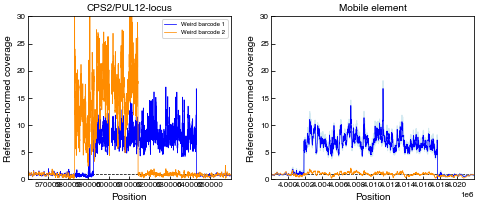

In [39]:
other_bc_cols = [5,6,8]
weird_bc1_cols = [1,2,3]
weird_bc2_cols = [5,6,8,11,12,13]


weird_bc1_summed_coverage = np.sum(clone_coverage_array[weird_bc1_cols], axis=0)
weird_bc2_summed_coverage = np.sum(clone_coverage_array[weird_bc2_cols], axis=0)
ref_coverage = clone_coverage_array[0] / np.median(clone_coverage_array[0])

median_normed_weird_bc1_reps = np.einsum('ij, i->ij', clone_coverage_array[weird_bc1_cols], np.median(clone_coverage_array[weird_bc1_cols], axis=1)**-1.)
median_normed_weird_bc2_reps = np.einsum('ij, i->ij', clone_coverage_array[weird_bc2_cols], np.median(clone_coverage_array[weird_bc2_cols], axis=1)**-1.)

min_normed_bc1_reps = np.min(median_normed_weird_bc1_reps, axis=0) / ref_coverage
max_normed_bc1_reps = np.max(median_normed_weird_bc1_reps, axis=0) / ref_coverage

min_normed_bc2_reps = np.min(median_normed_weird_bc2_reps, axis=0) / ref_coverage
max_normed_bc2_reps = np.max(median_normed_weird_bc2_reps, axis=0) / ref_coverage


median_normed_weird_bc1 = weird_bc1_summed_coverage / np.median( weird_bc1_summed_coverage ) / ref_coverage
median_normed_weird_bc2 = weird_bc2_summed_coverage / np.median( weird_bc2_summed_coverage ) / ref_coverage

# median_normed_weird_bc1 /= (ref_coverage / np.median(ref_coverage))
# median_normed_weird_bc2 /= (ref_coverage / np.median(ref_coverage))

fig, axs = plt.subplots(ncols=2, figsize=(8,3))
ax = axs[0]
ax.plot(indexed_positions, median_normed_weird_bc1, color='blue', label='Weird barcode 1')
# ax.fill_between(indexed_positions, min_normed_bc1_reps, max_normed_bc1_reps, color='lightblue', alpha=0.5)
ax.plot(indexed_positions, median_normed_weird_bc2, color='darkorange', label='Weird barcode 2')
# ax.fill_between(indexed_positions, min_normed_bc2_reps, max_normed_bc2_reps, color='wheat', alpha=0.5)
# ax.plot(indexed_positions, ref_coverage, color='grey', label='Reference')
ax.axhline(1, color='black', linestyle='dashed', zorder=0)
ax.set_xlim(560000, 660000)
ax.set_xticks(np.arange(570000, 660000, 10000))
ax.set_ylim(0, 30)
ax.set_ylabel('Reference-normed coverage')
ax.set_title('CPS2/PUL12-locus')
ax.set_xlabel('Position')
ax.set_rasterization_zorder(10**5)
ax.legend()

ax = axs[1]
ax.plot(indexed_positions, median_normed_weird_bc1, color='blue', label='Weird barcode 1')
ax.plot(indexed_positions, median_normed_weird_bc2, color='darkorange', label='Weird barcode 2')
ax.fill_between(indexed_positions, min_normed_bc1_reps, max_normed_bc1_reps, color='lightblue', alpha=0.5)
# ax.plot(indexed_positions, ref_coverage, color='grey', label='Reference')
ax.axhline(1, color='black', linestyle='dashed', zorder=0)
ax.set_xlim(3998000, 4022000)
ax.set_xticks(np.arange(4000000, 4022000, 2000))
ax.set_title('Mobile element')
ax.set_xlabel('Position')
ax.set_ylim(0, 30)
ax.set_ylabel('Reference-normed coverage')
# ax.legend()
ax.set_rasterization_zorder(10**5)

fig.savefig(f'{figures_dir}/fig4_LE_barcode_coverage.pdf')
plt.rcParams['svg.fonttype'] = 'none'
fig.savefig(f'{figures_dir}/fig4_LE_barcode_coverage.svg', format='svg')


In [4]:
with open(f'{pickled_dir}/barcode_clone_map.pkl', 'rb') as f:
    barcode_clone_map = pickle.load(f)
for barcode in barcode_clone_map:
    print(barcode, barcode_clone_map[barcode])


TCCGTTAACCTTCATAGTTG {'all': [(8, 17, 20), (9, 17, 19), (9, 17, 1), (6, 17, 6), (10, 17, 31), (10, 17, 25), (9, 17, 18), (9, 17, 24), (6, 17, 3), (6, 17, 2), (10, 17, 34), (10, 17, 20), (8, 17, 19), (10, 17, 36), (6, 17, 1), (8, 17, 24), (9, 51, 1), (6, 17, 12), (8, 17, 2), (6, 51, 7), (8, 36, 35), (8, 36, 34), (8, 36, 24), (8, 17, 5), (6, 17, 29), (10, 51, 15), (8, 17, 4), (7, 17, 3), (8, 36, 19), (4, 51, 23), (8, 36, 33), (7, 17, 10), (8, 36, 32), (6, 17, 26), (7, 17, 35), (5, 51, 14), (8, 36, 16), (8, 36, 28), (5, 51, 16), (6, 17, 31), (8, 17, 8), (7, 17, 27), (5, 51, 12), (9, 36, 28), (7, 17, 8), (7, 17, 25), (7, 17, 18), (7, 17, 24), (8, 17, 15), (9, 17, 13), (9, 17, 12), (8, 17, 16), (7, 51, 16), (6, 36, 27), (9, 17, 9), (8, 17, 13), (10, 17, 28), (8, 17, 12), (9, 17, 14), (8, 17, 10), (6, 17, 9), (6, 17, 8), (8, 17, 11)], 17: [(8, 17, 20), (9, 17, 19), (9, 17, 1), (6, 17, 6), (10, 17, 31), (10, 17, 25), (9, 17, 18), (9, 17, 24), (6, 17, 3), (6, 17, 2), (10, 17, 34), (10, 17, 20)

In [ ]:
### Show same amplification in experiment 2

